In [2]:
import sionna.rt as rt
import mitsuba as mi
import numpy as np
import drjit as dr
import matplotlib.pyplot as plt

In [4]:
def default_array(num_rows: int = 1, num_cols: int = 1,
                  vertical_spacing: float = 0.5, horizontal_spacing: float = 0.5,
                  pattern: str = "iso", polarization: str = "V"):
    return rt.PlanarArray(num_rows=num_rows,
                       num_cols=num_cols,
                       vertical_spacing=vertical_spacing,
                       horizontal_spacing=horizontal_spacing,
                       pattern=pattern,
                       polarization=polarization)

In [5]:
N = 100
vert_x, vert_y = np.meshgrid(
    np.linspace(0, 10, N),
    np.linspace(0, 10, N),
    indexing="xy")
elevation = (np.sin(2 * vert_x) + np.sin(2 * vert_y)) / 2 / 10
mesh = rt.utils.geometry.triangulate_elevation(mi.TensorXf(elevation))
vertices = dr.reshape(mi.Point3f, mesh.vertex_positions_buffer(), (3, -1))


# Create scene
props = mi.Properties()
props["material"] = rt.RadioMaterial(
    name="lunar-highland",
    thickness=11,
    relative_permittivity=2.7,
    conductivity=10**(-12.5),
    scattering_coefficient=0.4,
    xpd_coefficient=0.1,
    scattering_pattern='lambertian',
    frequency_update_callback=None,
    color=None,
    props=None)
# props["material"] = rt.ITURadioMaterial("mat", itu_type="concrete", thickness=10)
# props["material"] = rt.ITURadioMaterial("mat", itu_type="glass", thickness=1)
# props["material"] = rt.RadioMaterial("mat", thickness=10, relative_permittivity=100)
# Sionna requires bsdfs to be wrapped in HolderMaterial
props["material"] = rt.HolderMaterial(props)
mi_mesh = mi.Mesh(name="terrain",
                  vertex_count=mesh.vertex_count(),
                  face_count=mesh.face_count(), 
                  props=props)
mesh_params = mi.traverse(mesh)
mi_mesh_params = mi.traverse(mi_mesh)
mi_mesh_params["vertex_positions"] = mesh_params["vertex_positions"]
mi_mesh_params["faces"] = mesh_params["faces"]
mi_mesh_params.update()
scene = rt.Scene(mi.load_dict({
    "type": "scene",
    "terrain": mi_mesh
}))

scene.tx_array = default_array()
scene.rx_array = default_array(polarization="VH")
tx = rt.Transmitter(name="tx",
                 position=mi.Point3f(0, 0, 0.1),
                 orientation=mi.Point3f(0,0,0),
                 power_dbm=10)
tx.display_radius = 0.01
scene.add(tx)

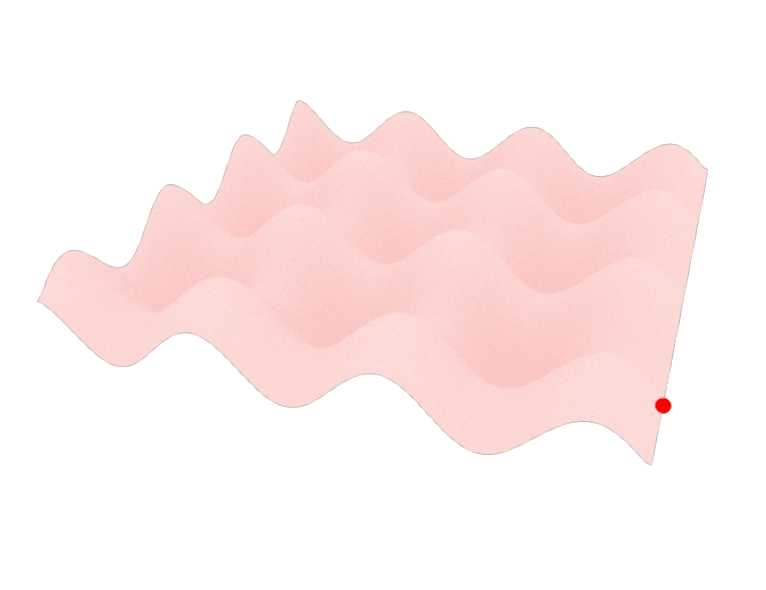

In [6]:
cam = rt.Camera(position=[-1, 0, 0.8], look_at=[0.3, 0.5, 0])
scene.render(camera=cam, show_devices=True);

In [ ]:
specular_reflection = True
diffuse_reflection = True
refraction=True 
max_depth = 10
los = True

In [ ]:
def compute_rm(offset):
    meas_surface = rt.utils.geometry.triangulate_elevation(mi.TensorXf(elevation + offset))

    rm_solver = rt.RadioMapSolver()
    rm_solver.loop_mode = "evaluated"
    rm: rt.MeshRadioMap = rm_solver(
        scene=scene,
        cell_size=[10, 10],
        measurement_surface=meas_surface, 
        samples_per_tx=int(1e7),
        max_depth=max_depth,
        los=los,
        specular_reflection=specular_reflection,
        diffuse_reflection=diffuse_reflection,
        refraction=refraction)
    return rm

In [67]:
from tqdm import tqdm

back_cam = rt.Camera(position=[-1, 1, 1.5], look_at=[0.4, 0.5, 0.1])
grids = []
images = []
offsets = [0.01, 0.001, 0.0001]
for offset in tqdm(offsets):
    rm = compute_rm(offset)
    path_gain_grid = np.nanmean(rm.path_gain.numpy().reshape(2, N, N), axis=0)
    grids.append(path_gain_grid)
    bitmap = scene.render(camera=back_cam, show_devices=True, radio_map=rm, num_samples=256, return_bitmap=True)
    image = np.clip(np.power(np.array(bitmap), 1/2.2), 0, 1)
    images.append(image) 
# scene.preview(show_devices=True, radio_map=rm_mesh);

100%|██████████| 3/3 [00:18<00:00,  6.09s/it]


-80.0 -26.842670440673828


/var/folders/dp/9xqdy2vn535883dxlm82nwtc0000gn/T/ipykernel_35544/986360644.py:7: RuntimeWarning: divide by zero encountered in log10
  grids_db = 10 * np.log10(grids)


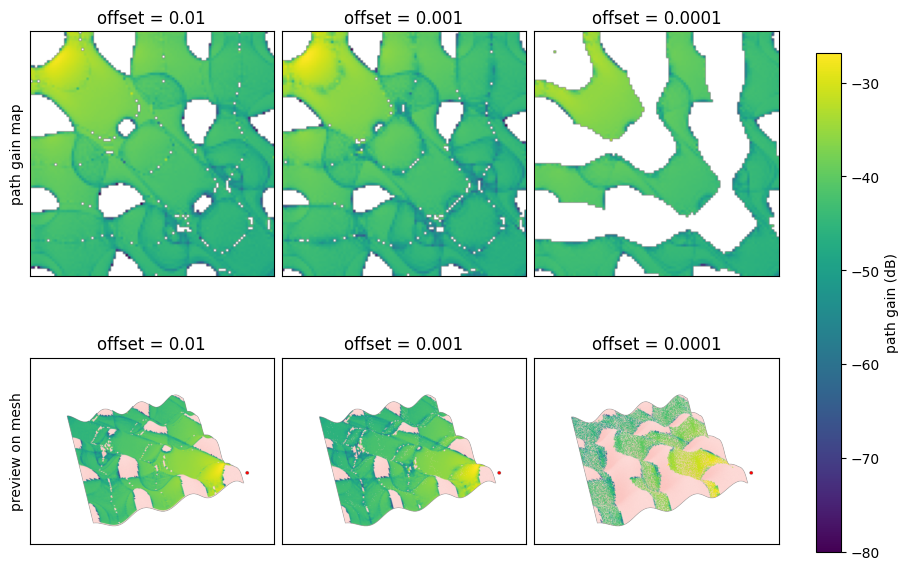

In [68]:
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

fig, axs = plt.subplots(nrows=2, ncols=3, constrained_layout=True)
# fig.get_layout_engine().set(w_pad=0.01, h_pad=0.01, hspace=0.01, wspace=0.1)
fig.set_size_inches(9, 6)
grids_db = 10 * np.log10(grids)
norm = Normalize(-80, np.nanmax(grids_db))
print(norm.vmin, norm.vmax)
if norm.vmin == 0:
    norm.vmin = 1e-8
for ax in axs.flat:
    ax.set(xticks=[], yticks=[])
for i, offset in enumerate(offsets):
    axs[0, i].imshow(grids_db[i], norm=norm)
    axs[1, i].imshow(images[i])
    # labels
    axs[0, i].set_title(f"offset = {offset}")
    axs[1, i].set_title(f"offset = {offset}")
axs[0, 0].set_ylabel("path gain map")
axs[1, 0].set_ylabel("preview on mesh")
plt.colorbar(ScalarMappable(norm), ax=axs, shrink=0.85, label="path gain (dB)")

In [69]:
# scene.render(camera=cam, show_devices=True, radio_map=rm);
scene.preview(show_devices=True, radio_map=rm);